In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [2]:
sample = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv')
sample.to_csv("submission.csv", index =False)

# **EDA** 

In [3]:
import hashlib
import matplotlib.pyplot as plt
import re
from collections import Counter

In [4]:
train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')
train.head()
test.head()

,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...
3,4,What is the significance of the redshift-dista...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...
4,5,What is the Landau-Lifshitz-Gilbert equation u...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...


Shape and columns of train and test data

In [5]:
print("Train shape:", train.shape)
print("\nTest shape:", test.shape)
print("\nTrain cloumns:", list(train.columns))
print("\nTest columns:", list(test.columns))

Train shape: (2000, 8)

Test shape: (500, 7)

Train cloumns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']

Test columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E']


Missing values in train and test datasets

In [6]:
print("Missing values in train:", train.isnull().sum())
print("Missing values in test:", test.isnull().sum())

Missing values in train: id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64
Missing values in test: id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64


In [7]:
answer_counts = train["answer"].value_counts()
print(answer_counts)

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64


Text(0, 0.5, 'Count')

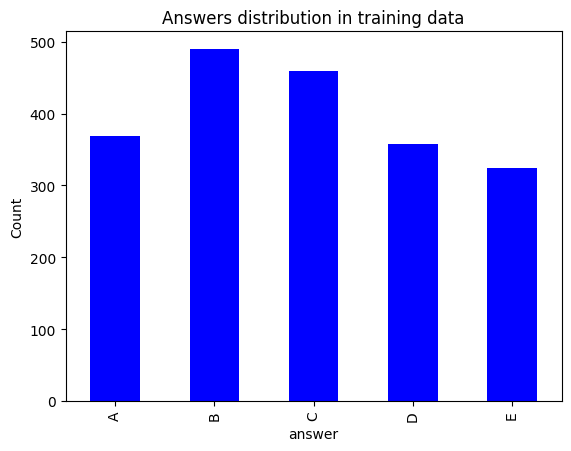

In [8]:
answer_counts.sort_index().plot(kind="bar", color="b",title="Answers distribution in training data")
plt.ylabel("Count")

In [9]:
dup_in_train = train.duplicated(subset=["prompt", "A","B","C","D","E"]).sum()
print("Total duplicates rows/questions which also have same options :",dup_in_train)

Total duplicates rows/questions which also have same options : 183


In [10]:
OPTIONS = ["A","B","C","D","E"]
def option_hash(row):
    key = "|".join(str(row[c]).strip().lower() for c in OPTIONS)
    return hashlib.md5(key.encode()).hexdigest()

train["Question_hash"] = train.apply(option_hash, axis=1)
test["Question_hash"] = test.apply(option_hash, axis=1)
print("Train Hashes:\n",train["Question_hash"])
print("Test Hashes:\n",test["Question_hash"])

Train Hashes:
 0       f357d591b31b3eba240ca8d942833833
1       c35a7aba1a83f5a441971035bc99d7ef
2       6a9b81d55d1bad0b7308c5162ae1f87e
3       f357d591b31b3eba240ca8d942833833
4       d1be288b8262aa1f5824c66f59b4a79e
                      ...               
1995    a0853108228c61d2a5a301742f276e18
1996    7c5f672eea96463a042583f9f50f8caf
1997    fd20c67c0da057beb21c8ebce3111d5e
1998    8bed18ff710ff3cf0a56f5df0958659e
1999    8c26830d7bd7c6842010ddf25de7f6f0
Name: Question_hash, Length: 2000, dtype: object
Test Hashes:
 0      d17c7a7a5f59f015c8db6b3babf37ae2
1      97589c5fd21a4117ef6c744c76823447
2      a0041984581a151e045a2f936d568495
3      314b033197504a1c8147d39eda238305
4      f5901bf99f5c7650da0989ec3591c0f5
                     ...               
495    cbe762150e1da58ad0920d06ab4458cd
496    ea70cf0b200dc407351bbaeea4031c15
497    b85da30e7bdaea4241fd934b1e1d012d
498    3e52eb92dd7d305a4506276e6fc0ca64
499    ad0edb2f209823eae1a9a63a290788f6
Name: Question_hash, Length: 50

In [11]:
print("Unique Questions in Train out of total questions:\n", train["Question_hash"].nunique(),"/",len(train))
print("Unique Questions in Test out of total questions:\n", test["Question_hash"].nunique(),"/",len(test))

Unique Questions in Train out of total questions:
 588 / 2000
Unique Questions in Test out of total questions:
 269 / 500


In [12]:
overlap_hash = set(test["Question_hash"]).intersection(set(train["Question_hash"]))
pct = len(overlap_hash) / test["Question_hash"].nunique() * 100
print(f"{len(overlap_hash)} of {test['Question_hash'].nunique()} unique test questions ")
print(f"({pct:.1f}%) reuse the exact same option set as a train question.")

227 of 269 unique test questions 
(84.4%) reuse the exact same option set as a train question.


In [13]:
answers_per_group = train.groupby("Question_hash")["answer"].nunique()
n_inconsistent = (answers_per_group > 1).sum()
print("Question groups with inconsistent answers:",n_inconsistent)
print("out of",train['Question_hash'].nunique())

Question groups with inconsistent answers: 0
out of 588


In [14]:
def longest_option(row):
    lengths = {opt: len(str(row[opt])) for opt in OPTIONS}
    return max(lengths, key=lengths.get)
 
train["longest_opt"] = train.apply(longest_option, axis=1)
match_rate = (train["longest_opt"] == train["answer"]).mean()*100
print(f"Longest-option heuristic accuracy: {match_rate:.3f}")

Longest-option heuristic accuracy: 40.550


In [15]:
dedup = train.drop_duplicates(subset="Question_hash")
print(f"Answer count after removing the duplicates{dedup["answer"].value_counts()}")
print(f"Answer count before the removing the duplicates:{train["answer"].value_counts()}")

Answer count after removing the duplicatesanswer
C    165
B    134
D    123
E     87
A     79
Name: count, dtype: int64
Answer count before the removing the duplicates:answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64


In [16]:
for column in ["prompt"] + OPTIONS:
    n_empty = (train[column].astype(str).str.strip() == "").sum()
    print(f"Empty or whitespaces values in '{column}':{n_empty}")
def has_non_ascii(s):
    return any(ord(c) >127 for c in str(s))
n_non_ascii = train["prompt"].apply(has_non_ascii).sum()
print(f"Prompts containing non-ASCII characters: {n_non_ascii}")
if n_non_ascii:
    print(train.loc[train["prompt"].apply(has_non_ascii), "prompt"].head(3).tolist())

Empty or whitespaces values in 'prompt':0
Empty or whitespaces values in 'A':0
Empty or whitespaces values in 'B':0
Empty or whitespaces values in 'C':0
Empty or whitespaces values in 'D':0
Empty or whitespaces values in 'E':0
Prompts containing non-ASCII characters: 12
['Select the most accurate option: What is the reason behind the adoption of a logarithmic scale of 5√100 ≈ 2.512 between magnitudes in astronomy? from the following choices.', 'What is the reason behind the adoption of a logarithmic scale of 5√100 ≈ 2.512 between magnitudes in astronomy?', 'Determine the correct option: What is the reason behind the adoption of a logarithmic scale of 5√100 ≈ 2.512 between magnitudes in astronomy? among the listed options.']


In [17]:
def clean_prompt(p):
    p = re.sub(r"^[A-Za-z ,]+:\s*","",str(p))
    p = re.sub(r"(among the listed options\.|frm the following choices\.|carefully|.)$","",p)
    return p
    
def word_overlap(prompt_words, opt_text):
    opt_words = set(re.findall(r"\w+", str(opt_text).lower()))
    return len(prompt_words & opt_words)

ranks = []
for _, row in train.iterrows():
    prompt_words = set(re.findall(r"\w+", clean_prompt(row["prompt"]).lower()))
    overlaps = {opt : word_overlap(prompt_words, row[opt]) for opt in OPTIONS}
    sorted_opts = sorted(overlaps, key=lambda k: -overlaps[k])
    ranks.append(sorted_opts.index(row["answer"]) + 1)


train["overlap_rank"] = ranks
print(f"Correct answer's word overlap rank vs the prompt: {train["overlap_rank"].value_counts().sort_index()}")
print(f"Mean rank: {train["overlap_rank"].mean():.5f}")

Correct answer's word overlap rank vs the prompt: overlap_rank
1    384
2    489
3    420
4    366
5    341
Name: count, dtype: int64
Mean rank: 2.89550


In [18]:
n_test_dupe_prompts = test["prompt"].duplicated().sum()
n_test_dupe_full = test.duplicated(subset=["prompt"] + OPTIONS).sum()
print(f"Duplicate prompts in test: {n_test_dupe_prompts}")
print(f"Fully duplicate rows in test: {n_test_dupe_full}")


domains = {
    "Physics": ["quantum", "energy", "force", "particle", "velocity", "gravity", "wave", "electron", "magnetic", "relativity"],
    "Biology": ["cell", "organism", "gene", "protein", "species", "evolution", "enzyme", "dna"],
    "Chemistry": ["molecule", "reaction", "acid", "compound", "element", "bond", "solution"],
    "Astronomy": ["star", "planet", "galaxy", "orbit", "universe", "solar", "black hole"],
    "Philosophy": ["ethics", "existential", "philosopher", "metaphysic", "moral", "consciousness"],
    "CS/Math": ["algorithm", "function", "equation", "matrix", "probability", "computation"],
}

def tag_domain(text):
    t = str(text).lower()
    for domain, kws in domains.items():
        if any(kw in t for kw in kws):
            return domain
    return "Other/Unclassified"
 
train["domain_guess"] = train["prompt"].apply(tag_domain)
print(train["domain_guess"].value_counts())

all_words = []
for p in train["prompt"]:
    cleaned = clean_prompt(p).lower()
    all_words.extend(re.findall(r"[a-z]{4,}", cleaned))  # words with 4+ letters
 
stopwords = {"what", "which", "does", "that", "with", "from", "this", "have",
             "following", "best", "most", "would", "when", "should"}
filtered = [w for w in all_words if w not in stopwords]
top_words = Counter(filtered).most_common(20)
print("Top 20 content words across all prompts:")
for word, count in top_words:
    print(f"  {word}: {count}")


Duplicate prompts in test: 8
Fully duplicate rows in test: 7
domain_guess
Other/Unclassified    1346
Physics                319
Astronomy              172
CS/Math                 84
Biology                 56
Chemistry               23
Name: count, dtype: int64
Top 20 content words across all prompts:
  based: 414
  context: 388
  given: 376
  choices: 369
  carefully: 329
  correct: 282
  between: 240
  relationship: 148
  reason: 103
  used: 102
  effect: 95
  significance: 91
  observed: 85
  statements: 82
  quantum: 72
  accurately: 71
  symmetry: 69
  main: 68
  physics: 67
  space: 64


# **Milestone 1** #

In [19]:
#question 1 
counts = train['answer'].value_counts()

print("Frequency Distribution:")
print(counts)

most_frequent = counts.max()
least_frequent = counts.min()

total_sum = most_frequent + least_frequent

print(f"\nMost frequent count: {most_frequent}")
print(f"Least frequent count: {least_frequent}")
print(f"Sum of most and least frequent options: {total_sum}")

Frequency Distribution:
answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

Most frequent count: 490
Least frequent count: 324
Sum of most and least frequent options: 814


In [20]:
#question 2 
import string
unique_words = set()
remove_punct_map = str.maketrans('', '', string.punctuation)
for text in train['prompt']:
    if isinstance(text, str): # Ensure the value is a string
        cleaned_text = text.lower().translate(remove_punct_map)
        
        unique_words.update(cleaned_text.split())
vocab_size = len(unique_words)

print(f"Total number of unique words (vocabulary size): {vocab_size}")

Total number of unique words (vocabulary size): 859


In [21]:
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

text = train['prompt'].iloc[0]

if isinstance(text, str):
    remove_punct_map = str.maketrans('', '', string.punctuation)
    
    cleaned_words = text.lower().translate(remove_punct_map).split()
    
    filtered_words = [word for word in cleaned_words if word not in ENGLISH_STOP_WORDS]
    
    words_left = len(filtered_words)
    
    print(f"Original word count: {len(cleaned_words)}")
    print(f"Words left after filtering: {words_left}")
else:
    print("The prompt in this row is not a string.")

Original word count: 22
Words left after filtering: 13


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

cols_to_combine = ['prompt', 'A', 'B', 'C', 'D', 'E']

actual_cols = [col for col in cols_to_combine if col in train.columns]

combined_text_series = train[actual_cols].fillna('').astype(str).agg(' '.join, axis=1)
combined_text_list = combined_text_series.tolist()

vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(combined_text_list)

vocab_size = X.shape[1]

print(f"Total number of feature columns (vocabulary size): {vocab_size}")

Total number of feature columns (vocabulary size): 2762


In [23]:
from sklearn.metrics.pairwise import cosine_similarity

prompt_text = str(train['prompt'].iloc[0])
option_a_text = str(train['A'].iloc[0])

prompt_vector = vectorizer.transform([prompt_text])
option_a_vector = vectorizer.transform([option_a_text])

similarity_matrix = cosine_similarity(prompt_vector, option_a_vector)

similarity_score = round(similarity_matrix[0][0], 5)

print(f"Cosine similarity between prompt and option A (Row 1): {similarity_score}")

Cosine similarity between prompt and option A (Row 1): 0.27202


In [24]:
from sklearn.metrics.pairwise import cosine_similarity

correct_predictions = 0
total_rows = len(train)
options = ['A', 'B', 'C', 'D', 'E']

for index, row in train.iterrows():
    prompt_text = str(row['prompt'])
    prompt_vec = vectorizer.transform([prompt_text])
    
    similarities = {}
    
    for opt in options:
        opt_text = str(row[opt])
        opt_vec = vectorizer.transform([opt_text])
        
        sim_score = cosine_similarity(prompt_vec, opt_vec)[0][0]
        similarities[opt] = sim_score
    
    best_option = max(similarities, key=similarities.get)
    
    if best_option == row['answer']:
        correct_predictions += 1

accuracy_percentage = (correct_predictions / total_rows) * 100

print(f"Total rows evaluated: {total_rows}")
print(f"Correct predictions: {correct_predictions}")
print(f"Accuracy of TF-IDF Cosine Similarity approach: {accuracy_percentage:.2f}%")

Total rows evaluated: 2000
Correct predictions: 271
Accuracy of TF-IDF Cosine Similarity approach: 13.55%


In [25]:
def calculate_ap3(ground_truth, predictions):
    """
    Calculates the Average Precision at 3 (AP@3) for a single question.
    """
    score = 0.0
    for i, p in enumerate(predictions[:3]):
        if p == ground_truth:
            score = 1.0 / (i + 1)
            break 
            
    return score

actual_answer = 'C'
model_predictions = ['C', 'A', 'B']

map3_score = calculate_ap3(actual_answer, model_predictions)

print(f"Ground Truth: {actual_answer}")
print(f"Predictions: {model_predictions}")
print(f"MAP@3 Score: {map3_score}")

Ground Truth: C
Predictions: ['C', 'A', 'B']
MAP@3 Score: 1.0


In [26]:
counts = train['answer'].value_counts()
top_3_answers = counts.nlargest(3).index.tolist()

print(f"Top 3 most frequent answers (Static Prediction): {top_3_answers}")

def calculate_ap3(ground_truth, predictions):
    score = 0.0
    for i, p in enumerate(predictions[:3]):
        if p == ground_truth:
            score = 1.0 / (i + 1)
            break
    return score

total_map3_score = 0.0
total_rows = len(train)

for index, row in train.iterrows():
    actual_answer = row['answer']
    
    total_map3_score += calculate_ap3(actual_answer, top_3_answers)

final_map3_score = total_map3_score / total_rows

print(f"Overall MAP@3 score of Majority Class baseline: {final_map3_score:.4f}")

Top 3 most frequent answers (Static Prediction): ['B', 'C', 'A']
Overall MAP@3 score of Majority Class baseline: 0.4213


In [27]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

options = ['A', 'B', 'C', 'D', 'E']

def calculate_ap3(ground_truth, predictions):
    for i, p in enumerate(predictions[:3]):
        if p == ground_truth:
            return 1.0 / (i + 1)
    return 0.0

total_map3_score = 0.0
total_rows = len(train)

for index, row in train.iterrows():
    prompt_text = str(row['prompt'])
    
    prompt_vec = vectorizer.transform([prompt_text])
    
    similarity_scores = {}
    for opt in options:
        opt_text = str(row[opt])
        opt_vec = vectorizer.transform([opt_text])
        
        sim_score = cosine_similarity(prompt_vec, opt_vec)[0][0]
        similarity_scores[opt] = sim_score

    sorted_options = sorted(similarity_scores, key=similarity_scores.get, reverse=True)
    
    top_3_predictions = sorted_options[:3]
    
    actual_answer = row['answer'] 
    total_map3_score += calculate_ap3(actual_answer, top_3_predictions)

final_map3_score = total_map3_score / total_rows

print(f"Pipeline Evaluation Summary")
print(f"---------------------------")
print(f"Total Rows Processed: {total_rows}")
print(f"Final Average MAP@3 Score: {final_map3_score:.4f}")

Pipeline Evaluation Summary
---------------------------
Total Rows Processed: 2000
Final Average MAP@3 Score: 0.2962
